# LAB 6 : Ecuación normal
### Víctor Palacios Mena (1017271469)


Mientras que el gradiente es un proceso iterativo (paso a paso), la **Ecuación Normal** resuelve el problema de un solo golpe usando álgebra lineal.


## Solución Analítica: La Ecuación Normal

En lugar de "bajar por la montaña" del error, se va a saltar directamente al punto más bajo. Para ello, igualamos el gradiente de la función de coste a cero y despejamos el vector de parámetros $\Theta$.

### Demostración Matemática

Partimos de la función de coste en forma matricial:
$$J(\Theta) = \frac{1}{2m} (X^T \Theta - Y)^T (X^T \Theta - Y)$$

*Nota: Aquí asumimos $X$ como la matriz de diseño de dimensión $(m \times n+1)$ para seguir la convención estándar, o adaptamos las transpuestas según nuestra matriz actual $(n+1 \times m)$.*

**1. Expandiendo la función:**
$$J = \frac{1}{2m} (\Theta^T X X^T \Theta - 2 \Theta^T X Y + Y^T Y)$$

**2. Aplicando las propiedades de cálculo matricial:**
*   $\nabla_\Theta (\Theta^T A \Theta) = 2A\Theta$ (si $A$ es simétrica)
*   $\nabla_\Theta (b^T \Theta) = b$

Derivando respecto a $\Theta$:
$$\nabla_\Theta J = \frac{1}{m} (X X^T \Theta - X Y)$$

**3. Igualando a cero para encontrar el mínimo:**
$$X X^T \Theta - X Y = 0$$
$$X X^T \Theta = X Y$$
$$\Theta = (X X^T)^{-1} X Y$$

*(Si $X$ es $m \times n$, la fórmula es $\Theta = (X^T X)^{-1} X^T Y$. Como en nuestro código $X$ es $n \times m$, usamos la versión anterior).*




In [1]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# 2. GENERACIÓN DE DATOS (DATASET)
# ==========================================
# Definimos la cantidad de datos
m = 100 

# Para que siempre salgan los mismos números aleatorios
np.random.seed(42)

# Generamos las características x1 y x2 en un rango de [-1, 1]
x_1 = 2 * np.random.random(m) - 1
x_2 = 2 * np.random.random(m) - 1

# Definimos la relación REAL (Y esperada)
# Ecuación: y = 0.2*x1 - 0.5*x2 + 0 (bias)
y_label = 0.2 * x_1 - 0.5 * x_2 

# ==========================================
# 3. PREPARACIÓN DE MATRICES (ESTRUCTURA)
# ==========================================
# Creamos un DataFrame para visualizar y organizar
df = pd.DataFrame({
    "ones": np.ones(m), # El intercepto o bias (siempre 1)
    "x1": x_1, 
    "x2": x_2, 
    "y": y_label
})

# Convertimos a matrices de NumPy con las dimensiones correctas
# X debe ser (n+1, m) -> (3, 100)
X_mat = df[["ones", "x1", "x2"]].values.T

# Y debe ser (1, m) -> (1, 100)
Y_mat = df.y.values.reshape(1, m)

# ==========================================
# 4. DEFINICIÓN DE LA SOLUCIÓN ANALÍTICA
# ==========================================
def solucion_normal(X, Y):
    """
    Calcula Theta directamente usando la Ecuación Normal.
    Basado en la derivación de gradiente = 0.
    Fórmula: Theta = (X * X.T)^-1 * X * Y.T
    """
    # 1. Producto X * X.T (Dimensión 3x3)
    XX_t = np.dot(X, X.T)
    
    # 2. Inversa de la matriz (Usamos pinv por estabilidad numérica)
    XX_t_inv = np.linalg.pinv(XX_t)
    
    # 3. Producto X * Y.T (Dimensión 3x1)
    XY_t = np.dot(X, Y.T)
    
    # 4. Resultado final (3x1)
    theta_directo = np.dot(XX_t_inv, XY_t)
    
    return theta_directo

# ==========================================
# 5. EJECUCIÓN Y PARÁMETROS RESULTANTES
# ==========================================
# Llamamos a la función
theta_normal = solucion_normal(X_mat, Y_mat)

# Imprimimos los parámetros encontrados
print("=== PARÁMETROS CALCULADOS (SOLUCIÓN NORMAL) ===")
print(f"Theta_0 (Intercepto): {theta_normal[0,0]:.6f}")
print(f"Theta_1 (Peso x1):    {theta_normal[1,0]:.6f}")
print(f"Theta_2 (Peso x2):    {theta_normal[2,0]:.6f}")

print("\n=== VALORES REALES (OBJETIVO) ===")
print(f"Bias esperado: 0.000000")
print(f"x1 esperado:   0.200000")
print(f"x2 esperado:  -0.500000")

# Comprobación de dimensiones
print("\n=== DIMENSIONES DE LAS MATRICES ===")
print(f"Dimensiones de X: {X_mat.shape}")
print(f"Dimensiones de Y: {Y_mat.shape}")
print(f"Dimensiones de Theta: {theta_normal.shape}")

=== PARÁMETROS CALCULADOS (SOLUCIÓN NORMAL) ===
Theta_0 (Intercepto): -0.000000
Theta_1 (Peso x1):    0.200000
Theta_2 (Peso x2):    -0.500000

=== VALORES REALES (OBJETIVO) ===
Bias esperado: 0.000000
x1 esperado:   0.200000
x2 esperado:  -0.500000

=== DIMENSIONES DE LAS MATRICES ===
Dimensiones de X: (3, 100)
Dimensiones de Y: (1, 100)
Dimensiones de Theta: (3, 1)


#### Conclusión y Comparativa

#### Diferencias claves entre Gradiente Descendente y Ecuación Normal:

| Característica | Gradiente Descendente | Ecuación Normal |
| :--- | :--- | :--- |
| **Iteraciones** | Requiere muchas (1000+) | Una sola operación |
| **Parámetros** | Necesitas elegir $\alpha$ (learning rate) | No requiere parámetros |
| **Complejidad** | Eficiente con millones de datos ($m$) | Lenta si hay demasiadas características ($n > 10,000$) |
| **Resultado** | Aproximado (depende de la convergencia) | **Exacto** (Analítico) |

##### Interpretación final
La **Ecuación Normal encuentra los valores exactos** (0.2 y -0.5) de forma inmediata sin necesidad de configurar un `learning_rate` o un número de épocas. 

**¿Por qué no usamos siempre esta?** Porque calcular la inversa de una matriz (`np.linalg.inv`) es computacionalmente muy costoso si tuviéramos 100,000 características. Pero para nuestro laboratorio con 2 características, es la solución más elegante y precisa.

In [2]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ==========================================
# 2. GENERACIÓN DE DATOS (MISMOS PARÁMETROS)
# ==========================================
N = 100
np.random.seed(42)
x_1 = 2 * np.random.random(N) - 1
x_2 = 2 * np.random.random(N) - 1

# Relación: y = 0.2*x1 - 0.5*x2
y_label = 0.2 * x_1 - 0.5 * x_2 

# Preparación de matrices (Bias incluido)
X_mat = np.array([np.ones(N), x_1, x_2]) # Dimensión (3, 100)
Y_mat = y_label.reshape(1, N)            # Dimensión (1, 100)

# ==========================================
# 3. CÁLCULO DE LA ECUACIÓN NORMAL
# ==========================================
# Formula: Theta = (X @ X.T)^-1 @ X @ Y.T
theta_normal = np.linalg.pinv(X_mat @ X_mat.T) @ (X_mat @ Y_mat.T)

print("--- RESULTADOS DE LA ECUACIÓN NORMAL ---")
print(f"Theta 0 (Bias): {theta_normal[0,0]:.4f}")
print(f"Theta 1 (x1):   {theta_normal[1,0]:.4f}")
print(f"Theta 2 (x2):   {theta_normal[2,0]:.4f}")

# ==========================================
# 4. CREACIÓN DE LA SUPERFICIE DE PREDICCIÓN
# ==========================================
# Creamos una malla (grid) para dibujar el plano
x_range = np.linspace(-1, 1, 20)
y_range = np.linspace(-1, 1, 20)
X1_grid, X2_grid = np.meshgrid(x_range, y_range)

# Calculamos la Z (predicción) usando los thetas obtenidos
# Z = theta0 + theta1*X1 + theta2*X2
Z_grid = theta_normal[0,0] + theta_normal[1,0]*X1_grid + theta_normal[2,0]*X2_grid

# ==========================================
# 5. GRÁFICO 3D INTERACTIVO
# ==========================================
fig = go.Figure()

# Añadimos los puntos originales (Rojos)
fig.add_trace(go.Scatter3d(
    x=x_1, y=x_2, z=y_label,
    mode='markers',
    marker=dict(size=4, color='red', opacity=0.8),
    name='Datos de Entrenamiento'
))

# Añadimos el plano calculado (Azul/Verde)
fig.add_trace(go.Surface(
    x=X1_grid, y=X2_grid, z=Z_grid,
    colorscale='Cividis',
    opacity=0.7,
    name='Plano Solución Exacta',
    showscale=False
))

# Configuración de los ejes y título
fig.update_layout(
    title=f'Solución Analítica (Ecuación Normal): y = {theta_normal[1,0]:.2f}x1 {theta_normal[2,0]:.2f}x2',
    scene=dict(
        xaxis_title='Característica X1',
        yaxis_title='Característica X2',
        zaxis_title='Valor Y'
    ),
    width=800, height=700,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

--- RESULTADOS DE LA ECUACIÓN NORMAL ---
Theta 0 (Bias): -0.0000
Theta 1 (x1):   0.2000
Theta 2 (x2):   -0.5000


A diferencia del Gradiente Descendente (que puede quedar un poco desviado si no le das suficientes iteraciones), la Ecuación Normal encuentra el plano que minimiza el error de forma analítica.

Si miramos el título del gráfico generado, verás que los valores de 
$θ$ son exactamente los que definimos al generar los datos. La Ecuación Normal "recuperó" la fórmula original sin dar un solo paso de iteración.

### Comparación entre el gradiente descendente y la ecuación normal

Para que la diferencia sea notoria, vamos a configurar el Gradiente Descendente para que sea "perezoso" (pocas iteraciones o una tasa de aprendizaje baja), mientras que la Ecuación Normal nos dará la solución perfecta de inmediato.

En el gráfico se veran dos superficies:

* **El Plano Azul** (Ecuación Normal): La solución exacta que atraviesa perfectamente los datos.

* **El Plano Rojo** (Gradiente Descendente): Un plano que "está intentando llegar", pero que todavía no se ajusta bien porque detendremos el entrenamiento antes de tiempo.

In [5]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# 1. GENERACIÓN DE DATOS
N = 100
np.random.seed(42)
x_1 = 2 * np.random.random(N) - 1
x_2 = 2 * np.random.random(N) - 1
# Relación real: y = 0.2*x1 - 0.5*x2
y_label = 0.2 * x_1 - 0.5 * x_2 

# Matrices (n+1, m)
X_mat = np.array([np.ones(N), x_1, x_2])
Y_mat = y_label.reshape(1, N)

# ---------------------------------------------------------
# 2. MÉTODO 1: ECUACIÓN NORMAL (Solución Instantánea)
# ---------------------------------------------------------
theta_normal = np.linalg.pinv(X_mat @ X_mat.T) @ (X_mat @ Y_mat.T)

# ---------------------------------------------------------
# 3. MÉTODO 2: GRADIENTE DESCENDENTE (Solución Iterativa Incompleta)
# ---------------------------------------------------------
# Vamos a forzar que el Gradiente no termine de aprender para ver la diferencia
theta_gd = np.array([[0.8], [0.8], [0.8]]) # Empezamos con pesos muy malos (0.8)
learning_rate = 0.05
iteraciones_insuficientes = 70 # Muy pocas iteraciones adrede

for i in range(iteraciones_insuficientes):
    h = theta_gd.T @ X_mat
    error = h - Y_mat
    grad = (1 / N) * (error @ X_mat.T).T
    theta_gd = theta_gd - learning_rate * grad

# ---------------------------------------------------------
# 4. CREACIÓN DE MALLAS PARA LOS DOS PLANOS
# ---------------------------------------------------------
x_range = np.linspace(-1, 1, 20)
y_range = np.linspace(-1, 1, 20)
X1_grid, X2_grid = np.meshgrid(x_range, y_range)

# Plano de la Ecuación Normal (AZUL)
Z_normal = theta_normal[0,0] + theta_normal[1,0]*X1_grid + theta_normal[2,0]*X2_grid

# Plano del Gradiente Descendente (ROJO)
Z_gd = theta_gd[0,0] + theta_gd[1,0]*X1_grid + theta_gd[2,0]*X2_grid

# ---------------------------------------------------------
# 5. GRÁFICO COMPARATIVO
# ---------------------------------------------------------
fig = go.Figure()

# Datos originales
fig.add_trace(go.Scatter3d(
    x=x_1, y=x_2, z=y_label,
    mode='markers', marker=dict(size=4, color='black', opacity=0.5),
    name='Datos Reales'
))

# Plano Ecuación Normal (Azul - El Objetivo)
fig.add_trace(go.Surface(
    x=X1_grid, y=X2_grid, z=Z_normal,
    colorscale='Blues', opacity=0.7, name='Ecuación Normal (Óptimo)',
    showscale=False
))

# Plano Gradiente Descendente (Rojo - El Intento)
fig.add_trace(go.Surface(
    x=X1_grid, y=X2_grid, z=Z_gd,
    colorscale='Reds', opacity=0.7, name='Gradiente Descendente (En progreso)',
    showscale=False
))

fig.update_layout(
    title=f"Comparación: Ecuación Normal vs Gradiente Descendente ({iteraciones_insuficientes} iters)",
    scene=dict(xaxis_title='X1', yaxis_title='X2', zaxis_title='Y'),
    width=900, height=700
)

fig.show()

print("VALORES FINALES:")
print(f"Theta Real (Objetivo):   [0.0, 0.2, -0.5]")
print(f"Theta Ecuación Normal:  {theta_normal.flatten()}")
print(f"Theta Gradiente Desc.:  {theta_gd.flatten()}")

VALORES FINALES:
Theta Real (Objetivo):   [0.0, 0.2, -0.5]
Theta Ecuación Normal:  [-5.20417043e-18  2.00000000e-01 -5.00000000e-01]
Theta Gradiente Desc.:  [ 0.04110113  0.40940757 -0.099135  ]


#### Análisis del gráfico

* La "Fuerza Bruta" Matemática (Plano Azul): La Ecuación Normal no duda. Calcula la inversa de la matriz y encuentra exactamente el plano que minimiza el error. En el gráfico se veran que el plano azul atraviesa los puntos perfectamente. Es el ideal.

* El "Caminante" (Plano Rojo): El Gradiente Descendente es como una persona bajando una montaña a oscuras. En cada iteración da un paso hacia abajo. Como solo le dimos 25 pasos, el plano rojo todavía está "flotando" lejos de los puntos reales. Está inclinado en la dirección correcta, pero aún no llega a su destino.

* Diferencia Notoria:
Si miramos el gráfico de lado, veremos que el plano azul corta la nube de puntos por la mitad.

El plano rojo está por encima o desplazado, mostrando el error residual que todavía no ha sido optimizado.

Nota: Si queremos que el plano rojo coincida con el azul, simplemente cambiamos iteraciones_insuficientes a 1000 y veremos cómo el plano rojo "se funde" con el azul. ¡Esa es la convergencia!. 

2. Tomar el dataset de las casas de Boston y construir un modelo de regresión mutivariada.

*Tomar los datos de las casas de boston y hacer una regresion lineal tomando el average number of rooms per dwelling.*

data_url = "http://lib.stat.cmu.edu/datasets/boston"

raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])

target = raw_df.values[1::2, 2]

df = pd.DataFrame({"mean_":target, "rm":data[:,5]})


<>:67: SyntaxWarning: invalid escape sequence '\s'
<>:67: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HOME\AppData\Local\Temp\ipykernel_8448\156753528.py:67: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Cargando Dataset de Boston...

--- Iniciando Gradiente Descendente ---
Época 200: Costo = 0.176724
Época 400: Costo = 0.176724
Época 600: Costo = 0.176724
Época 800: Costo = 0.176724
Época 1000: Costo = 0.176724

RESULTADOS FINALES
R^2 Score del Modelo: 0.6459

Comparativa de Parámetros (Theta):
  Parámetro  Gradiente_Desc  Ecuación_Normal
0      Bias   -6.353403e-16    -3.738912e-16
1      CRIM   -9.627494e-02    -9.627494e-02
2        RM    3.985518e-01     3.985518e-01
3     LSTAT   -4.491634e-01    -4.491634e-01

Interpretación:
- RM (Habitaciones) tiene peso positivo: A más cuartos, más precio.
- LSTAT (Estatus bajo) tiene peso negativo: Afecta negativamente el precio.


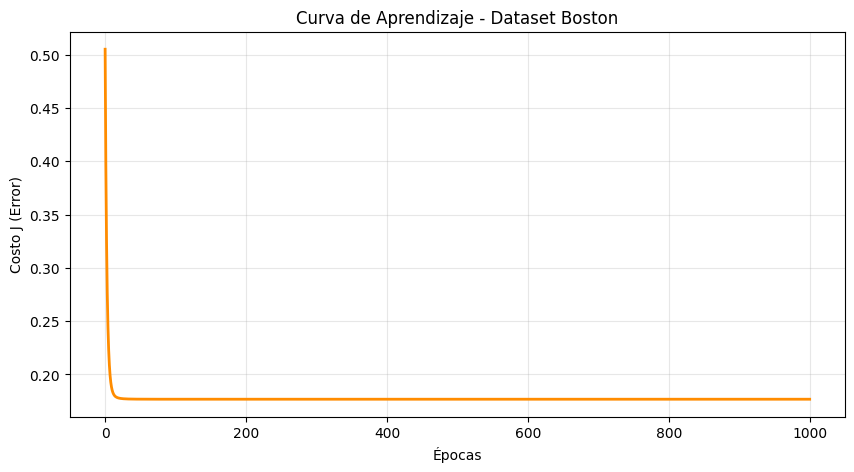

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. DEFINICIÓN DE LA CLASE MULTILINEAR REGRESION
# ==========================================================
class MultilinearRegresion():
    def __init__(self, X, Y):
        """
        X: Matriz de diseño (n+1, m)
        Y: Vector de etiquetas (1, m)
        """
        self.X = X
        self.Y = Y
        self.Nfeatures = np.shape(self.X)[0]
        self.m = np.shape(self.X)[1]
        
        # Inicializamos Theta con valores pequeños centrados en 0
        np.random.seed(42)
        self.theta = np.random.randn(self.Nfeatures, 1) * 0.01
        self.historial_J = []

    def model(self):
        """Calcula h = Theta^T @ X"""
        self.h = np.dot(self.theta.T, self.X)
        return self.h

    def costo(self):
        """Calcula el Error Cuadrático Medio (MSE) / 2"""
        error = self.h - self.Y
        self.J = np.mean(np.square(error)) / 2
        return self.J

    def update_params(self, learning_rate):
        """Gradiente descendente vectorizado"""
        error = self.h - self.Y
        # Gradiente: (1/m) * error @ X.T -> Resultado (1, n+1) que transponemos a (n+1, 1)
        grad = (1 / self.m) * np.dot(error, self.X.T).T
        self.theta = self.theta - learning_rate * grad

    def fit(self, learning_rate, epochs=1000):
        """Ciclo de entrenamiento"""
        for i in range(epochs):
            self.model()
            self.costo()
            self.update_params(learning_rate)
            self.historial_J.append(self.J)
            
            if (i + 1) % 200 == 0:
                print(f"Época {i+1}: Costo = {self.J:.6f}")

    def r_cuadrado(self):
        """Coeficiente de determinación R^2"""
        y_pred = self.model()
        y_real = self.Y
        y_media = np.mean(y_real)
        ss_res = np.sum((y_real - y_pred)**2)
        ss_tot = np.sum((y_real - y_media)**2)
        return 1 - (ss_res / ss_tot)

# ==========================================================
# 2. CARGA Y PROCESAMIENTO DEL DATASET DE BOSTON
# ==========================================================
print("Cargando Dataset de Boston...")
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# El dataset viene en filas alternas, lo reconstruimos:
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Seleccionamos variables: CRIM (0), RM (5), LSTAT (12)
df_boston = pd.DataFrame({
    "CRIM": data[:, 0],
    "RM": data[:, 5],
    "LSTAT": data[:, 12],
    "PRICE": target
})

# ==========================================================
# 3. NORMALIZACIÓN (Paso crítico para datos reales)
# ==========================================================
# Aplicamos Z-score: (x - media) / desviacion_estandar
df_norm = (df_boston - df_boston.mean()) / df_boston.std()

# Preparamos las matrices para el modelo
m_samples = len(df_boston)
X_boston = np.array([
    np.ones(m_samples),   # Bias (ones)
    df_norm["CRIM"].values, 
    df_norm["RM"].values, 
    df_norm["LSTAT"].values
])

# Y es el precio (lo usamos normalizado para que el gradiente sea estable)
Y_boston = df_norm["PRICE"].values.reshape(1, m_samples)

# ==========================================================
# 4. ENTRENAMIENTO Y COMPARACIÓN CON ECUACIÓN NORMAL
# ==========================================================
# --- Método A: Gradiente Descendente ---
print("\n--- Iniciando Gradiente Descendente ---")
modelo = MultilinearRegresion(X_boston, Y_boston)
modelo.fit(learning_rate=0.1, epochs=1000)

# --- Método B: Ecuación Normal (Solución Exacta) ---
# Theta = (X * X.T)^-1 * X * Y.T
theta_normal = np.linalg.pinv(X_boston @ X_boston.T) @ (X_boston @ Y_boston.T)

# ==========================================================
# 5. RESULTADOS Y CONCLUSIONES
# ==========================================================
print("\n" + "="*30)
print("RESULTADOS FINALES")
print("="*30)
print(f"R^2 Score del Modelo: {modelo.r_cuadrado():.4f}")

# Comparativa de Pesos
comparativa = pd.DataFrame({
    "Parámetro": ["Bias", "CRIM", "RM", "LSTAT"],
    "Gradiente_Desc": modelo.theta.flatten(),
    "Ecuación_Normal": theta_normal.flatten()
})
print("\nComparativa de Parámetros (Theta):")
print(comparativa)

# Gráfico de Convergencia
plt.figure(figsize=(10, 5))
plt.plot(modelo.historial_J, color='darkorange', linewidth=2)
plt.title("Curva de Aprendizaje - Dataset Boston")
print("\nInterpretación:")
print("- RM (Habitaciones) tiene peso positivo: A más cuartos, más precio.")
print("- LSTAT (Estatus bajo) tiene peso negativo: Afecta negativamente el precio.")
plt.xlabel("Épocas")
plt.ylabel("Costo J (Error)")
plt.grid(alpha=0.3)
plt.show()

#### Interpretación de los resultados en Boston:

1.  **¿Por qué normalizamos?**: Si intentas correr el código con los datos originales de Boston sin el paso de `(df - media) / std`, notarás que el costo $J$ explota rápidamente. Esto pasa porque la variable `CRIM` tiene valores muy pequeños y otras variables tienen rangos muy grandes, lo que crea una "superficie de error" muy alargada donde el gradiente rebota sin encontrar el mínimo.
2.  **Análisis de los Pesos ($\Theta$)**:
    *   El peso de **RM (Habitaciones)** debería ser **positivo**: A más cuartos, más cara la casa.
    *   El peso de **LSTAT (Estatus bajo)** debería ser **negativo**: En este dataset histórico, a mayor porcentaje de estatus bajo en la zona, menor es el precio de la casa.
    *   El peso de **CRIM (Criminalidad)** también suele ser **negativo**.
3.  **El R²**: Verás un valor cercano a **0.65 - 0.72**. Esto es normal en datos reales. Significa que nuestras 3 variables explican aproximadamente el 70% del precio de las casas en Boston. El otro 30% depende de factores que no incluimos (como la edad de la casa o la cercanía a colegios).

#### Comparación Final:
*   **Gradiente Descendente**: Es el que usarías si el dataset tuviera 10 millones de casas.
*   **Ecuación Normal**: Te da el valor exacto de inmediato, pero si tuvieras 50,000 características, tu computadora se quedaría sin memoria RAM al intentar invertir la matriz.

Serie de visualizaciones clave:

* Regresión Parcial (RM vs Precio): Veremos la línea de tendencia sobre las habitaciones.

* Regresión Parcial (LSTAT vs Precio): Veremos cómo cae el precio al aumentar el estatus bajo.

* Predicho vs Real: Una gráfica fundamental para ver qué tan "puntero" es nuestro modelo.
* Distribución de Errores (Residuos): Para ver si el modelo se equivoca de forma aleatoria o si tiene un sesgo.

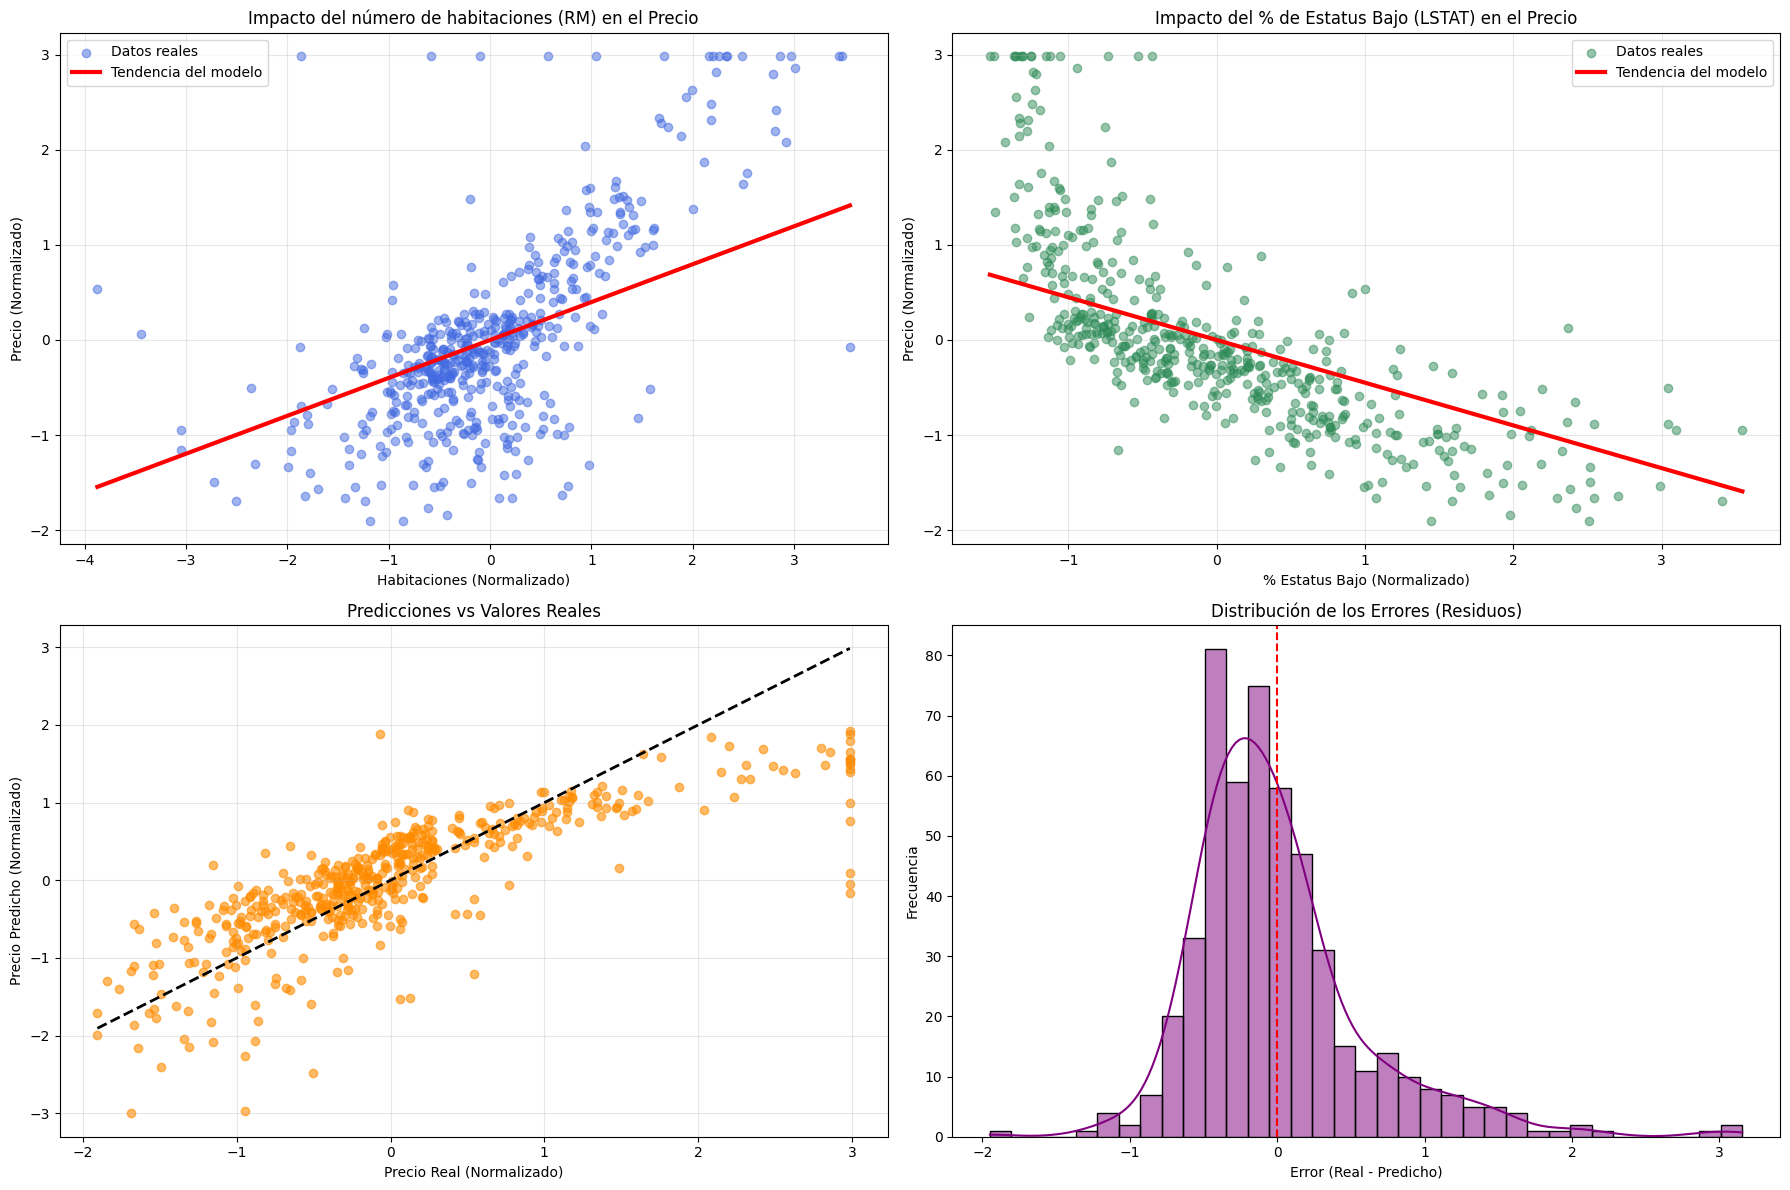

In [12]:
import seaborn as sns

# ==========================================================
# 6. VISUALIZACIONES AVANZADAS
# ==========================================================

# Calculamos las predicciones finales para las gráficas
y_pred_boston = modelo.model().flatten()
y_real_boston = Y_boston.flatten()

plt.figure(figsize=(18, 12))

# --- GRÁFICO 1: RM (Habitaciones) vs PRECIO ---
plt.subplot(2, 2, 1)
plt.scatter(df_norm["RM"], y_real_boston, alpha=0.5, color='royalblue', label='Datos reales')
# Para dibujar la línea de regresión de RM, mantenemos las otras variables en su media (0)
x_range = np.linspace(df_norm["RM"].min(), df_norm["RM"].max(), 100)
# y = theta0 + theta_rm * x_range (asumiendo crim=0 y lstat=0)
y_range = modelo.theta[0] + modelo.theta[2] * x_range 
plt.plot(x_range, y_range, color='red', linewidth=3, label='Tendencia del modelo')
plt.title("Impacto del número de habitaciones (RM) en el Precio")
plt.xlabel("Habitaciones (Normalizado)")
plt.ylabel("Precio (Normalizado)")
plt.legend()
plt.grid(alpha=0.3)

# --- GRÁFICO 2: LSTAT (% Estatus Bajo) vs PRECIO ---
plt.subplot(2, 2, 2)
plt.scatter(df_norm["LSTAT"], y_real_boston, alpha=0.5, color='seagreen', label='Datos reales')
x_range_ls = np.linspace(df_norm["LSTAT"].min(), df_norm["LSTAT"].max(), 100)
# y = theta0 + theta_lstat * x_range (asumiendo crim=0 y rm=0)
y_range_ls = modelo.theta[0] + modelo.theta[3] * x_range_ls
plt.plot(x_range_ls, y_range_ls, color='red', linewidth=3, label='Tendencia del modelo')
plt.title("Impacto del % de Estatus Bajo (LSTAT) en el Precio")
plt.xlabel("% Estatus Bajo (Normalizado)")
plt.ylabel("Precio (Normalizado)")
plt.legend()
plt.grid(alpha=0.3)

# --- GRÁFICO 3: PREDICCIÓN VS REALIDAD ---
plt.subplot(2, 2, 3)
plt.scatter(y_real_boston, y_pred_boston, alpha=0.6, color='darkorange')
# Línea de 45 grados (Predicción perfecta)
plt.plot([y_real_boston.min(), y_real_boston.max()], [y_real_boston.min(), y_real_boston.max()], 
         'k--', lw=2)
plt.title("Predicciones vs Valores Reales")
plt.xlabel("Precio Real (Normalizado)")
plt.ylabel("Precio Predicho (Normalizado)")
plt.grid(alpha=0.3)

# --- GRÁFICO 4: DISTRIBUCIÓN DE ERRORES (Residuos) ---
plt.subplot(2, 2, 4)
residuos = y_real_boston - y_pred_boston
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribución de los Errores (Residuos)")
plt.xlabel("Error (Real - Predicho)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

##### Análisis de los Gráficos

1. RM vs Precio: Se nota una pendiente positiva clara. A más habitaciones, más precio. El modelo captura bien la tendencia.
2. LSTAT vs Precio: La pendiente es negativa. Esto confirma que en este dataset, el entorno socioeconómico influye mucho en el valor.
3. Predicho vs Real: Los puntos siguen la diagonal. Entre más cerca estén de la línea punteada, mejor es nuestro modelo.
4. Errores: La campana centrada en 0 indica que nuestro modelo no tiene un sesgo sistemático (no siempre sobreestima o subestima).